In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv("train.csv")

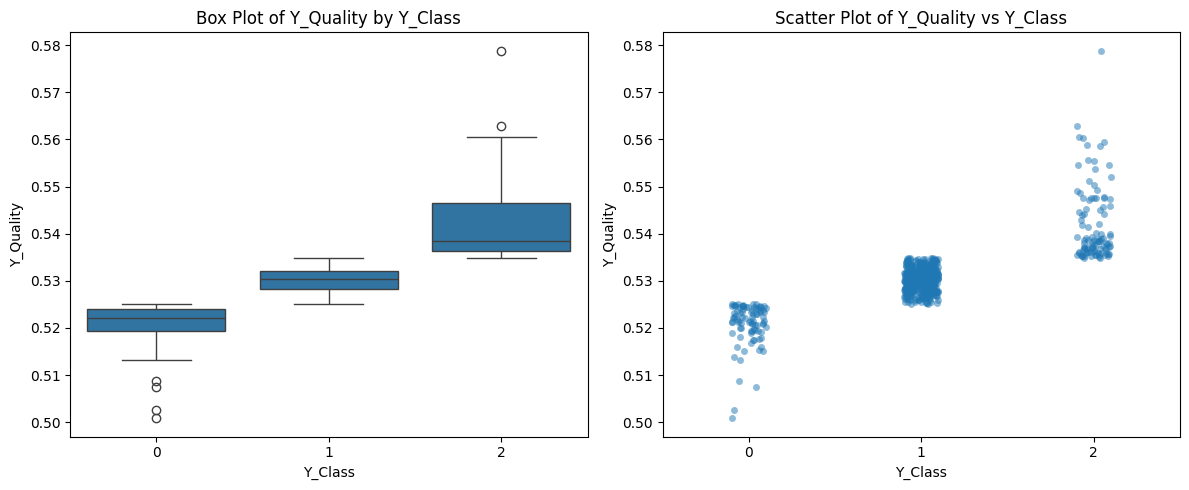

In [103]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 박스 플롯 (Y_Class별 Y_Quality 분포)
sns.boxplot(x = df["Y_Class"], y = df["Y_Quality"], ax=axes[0])
axes[0].set_title("Box Plot of Y_Quality by Y_Class")
axes[0].set_xlabel("Y_Class")
axes[0].set_ylabel("Y_Quality")

# 산점도 (Y_Class와 Y_Quality 관계)
sns.stripplot(x = df["Y_Class"], y = df["Y_Quality"], jitter=True, alpha=0.5, ax=axes[1])
axes[1].set_title("Scatter Plot of Y_Quality vs Y_Class")
axes[1].set_xlabel("Y_Class")
axes[1].set_ylabel("Y_Quality")

plt.tight_layout()
plt.show()

In [104]:
df["Month"] = pd.to_datetime(df["TIMESTAMP"]).dt.month
df["Hour"] = pd.to_datetime(df["TIMESTAMP"]).dt.hour
df["Day"] = pd.to_datetime(df["TIMESTAMP"]).dt.day
df["Minute"] = pd.to_datetime(df["TIMESTAMP"]).dt.minute

df.head()

,PRODUCT_ID,Y_Class,Y_Quality,TIMESTAMP,LINE,PRODUCT_CODE,X_1,X_2,X_3,X_4,...,X_2870,X_2871,X_2872,X_2873,X_2874,X_2875,Month,Hour,Day,Minute
0,TRAIN_000,1,0.533433,2022-06-13 5:14,T050304,A_31,NaN,NaN,NaN,NaN,...,77.77,NaN,NaN,NaN,NaN,NaN,6,5,13,14
1,TRAIN_001,2,0.541819,2022-06-13 5:22,T050307,A_31,NaN,NaN,NaN,NaN,...,72.55,NaN,NaN,NaN,NaN,NaN,6,5,13,22
2,TRAIN_002,1,0.531267,2022-06-13 5:30,T050304,A_31,NaN,NaN,NaN,NaN,...,78.35,NaN,NaN,NaN,NaN,NaN,6,5,13,30
3,TRAIN_003,2,0.537325,2022-06-13 5:39,T050307,A_31,NaN,NaN,NaN,NaN,...,71.78,NaN,NaN,NaN,NaN,NaN,6,5,13,39
4,TRAIN_004,1,0.531590,2022-06-13 5:47,T050304,A_31,NaN,NaN,NaN,NaN,...,76.97,NaN,NaN,NaN,NaN,NaN,6,5,13,47


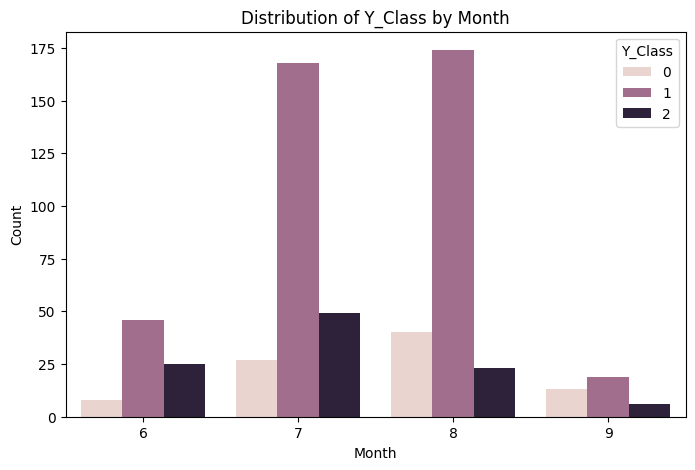

In [105]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Month", hue="Y_Class")
plt.title("Distribution of Y_Class by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend(title="Y_Class")
plt.show()

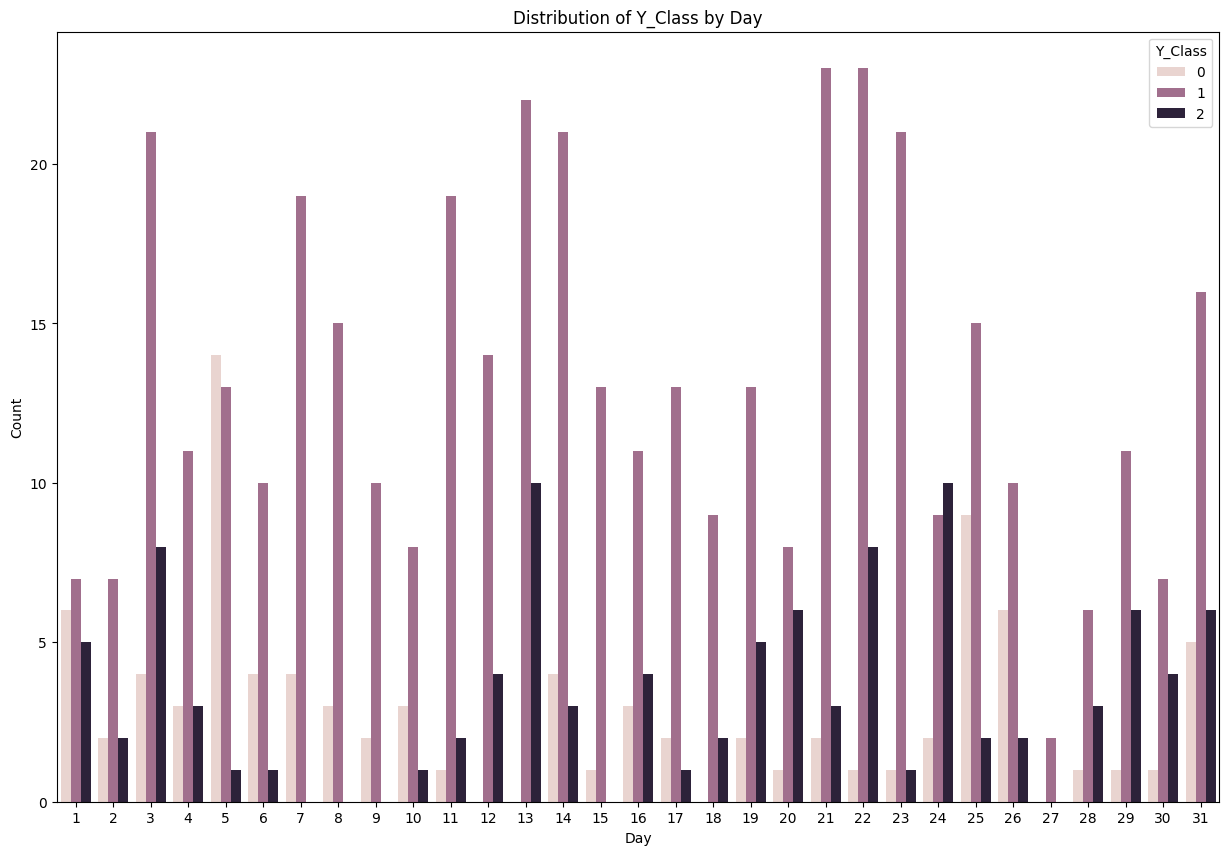

In [106]:
plt.figure(figsize=(15, 10))
sns.countplot(data=df, x="Day", hue="Y_Class")
plt.title("Distribution of Y_Class by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend(title="Y_Class")
plt.show()

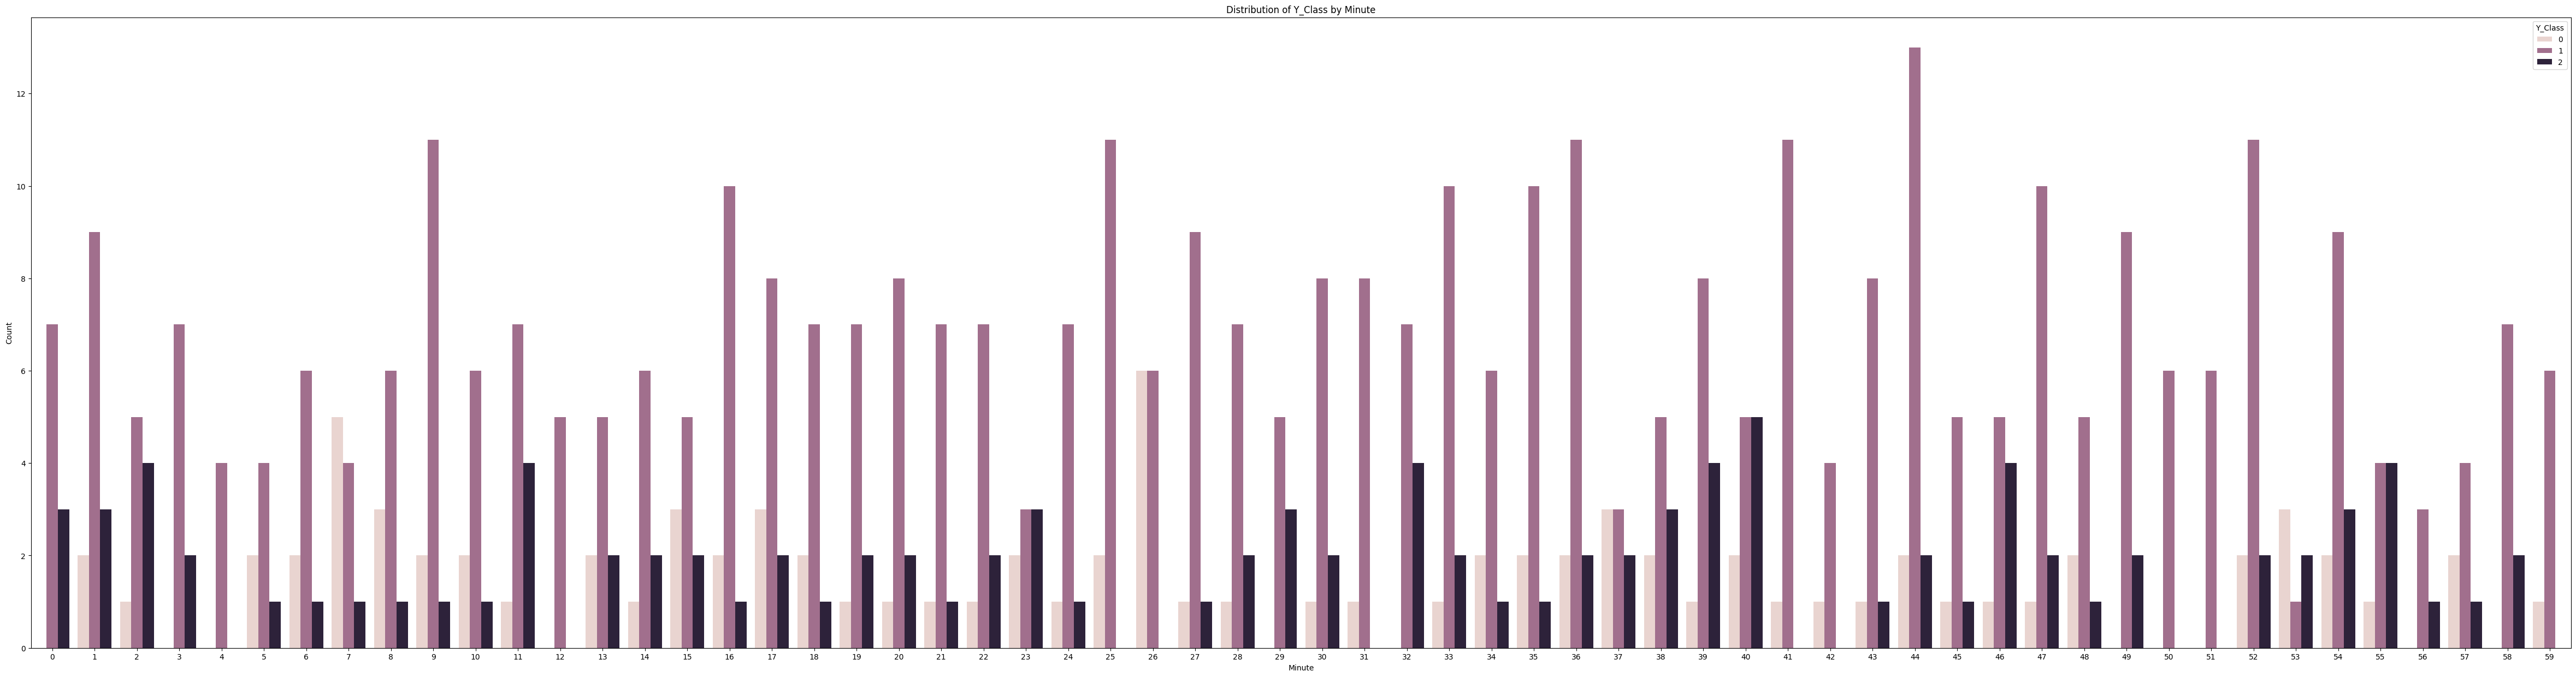

In [107]:
plt.figure(figsize=(60, 15))
sns.countplot(data=df, x="Minute", hue="Y_Class")
plt.title("Distribution of Y_Class by Minute")
plt.xlabel("Minute")
plt.ylabel("Count")
plt.legend(title="Y_Class")
plt.show()

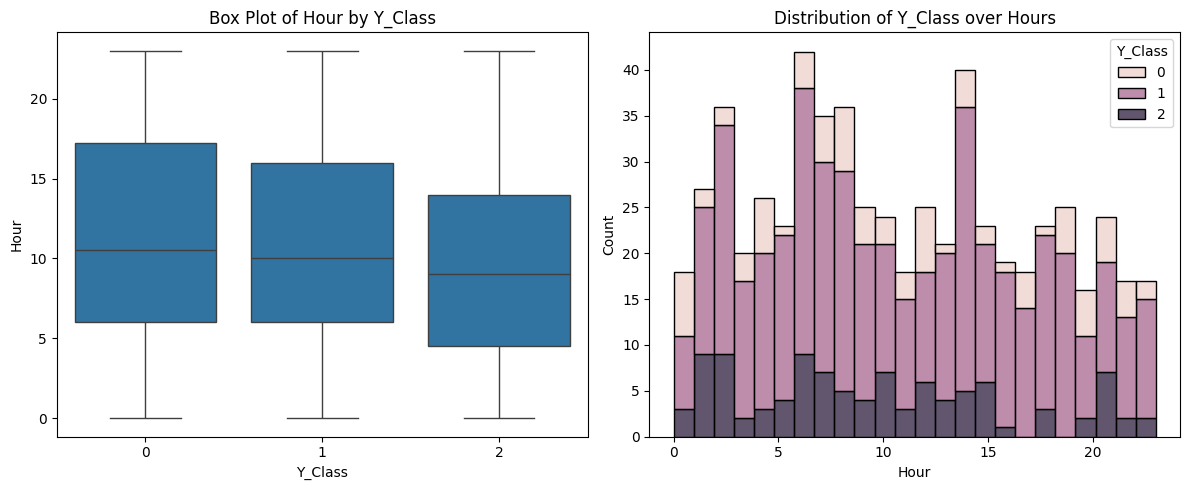

In [108]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 박스 플롯 (Y_Class별 Hour 분포)
sns.boxplot(x = df["Y_Class"], y = df["Hour"], ax=axes[0])
axes[0].set_title("Box Plot of Hour by Y_Class")
axes[0].set_xlabel("Y_Class")
axes[0].set_ylabel("Hour")

# 히스토그램 (시간대별 Y_Class 분포)
sns.histplot(data = df, x="Hour", hue="Y_Class", multiple="stack", bins=24, ax=axes[1])
axes[1].set_title("Distribution of Y_Class over Hours")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

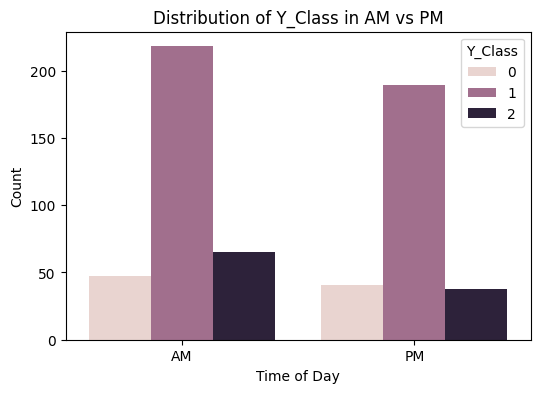

In [109]:
# 오전(AM)과 오후(PM) 구분
df["Time_of_Day"] = df["Hour"].apply(lambda x: "AM" if x < 12 else "PM")

# 시각화: Y_Class별 오전/오후 분포
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Time_of_Day", hue="Y_Class")
plt.title("Distribution of Y_Class in AM vs PM")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.legend(title="Y_Class")
plt.show()

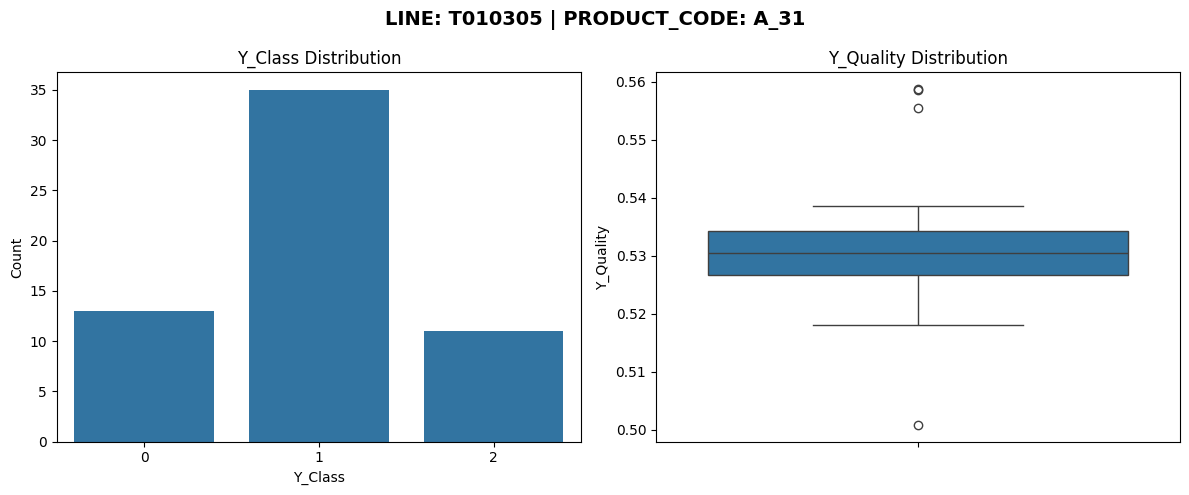

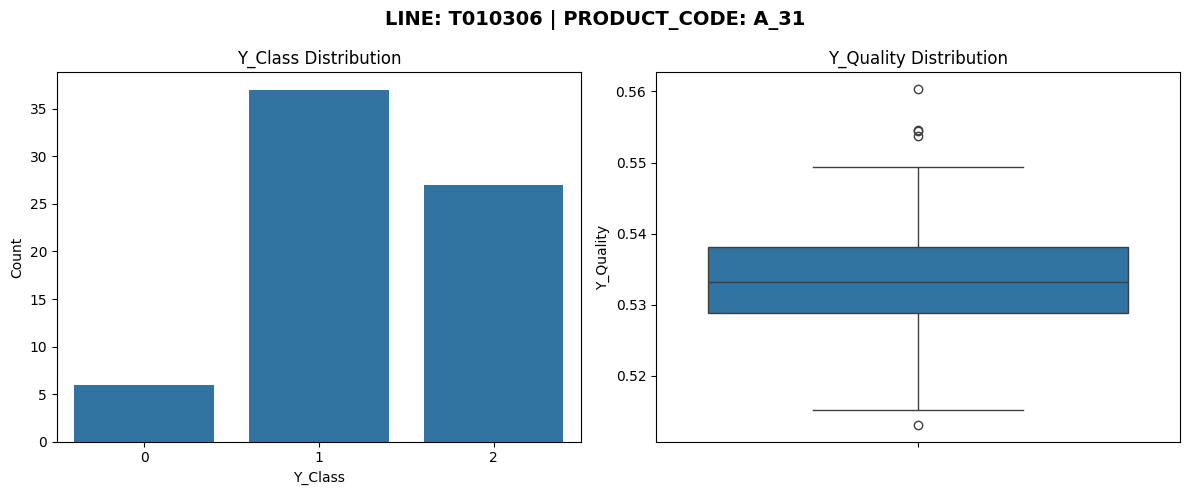

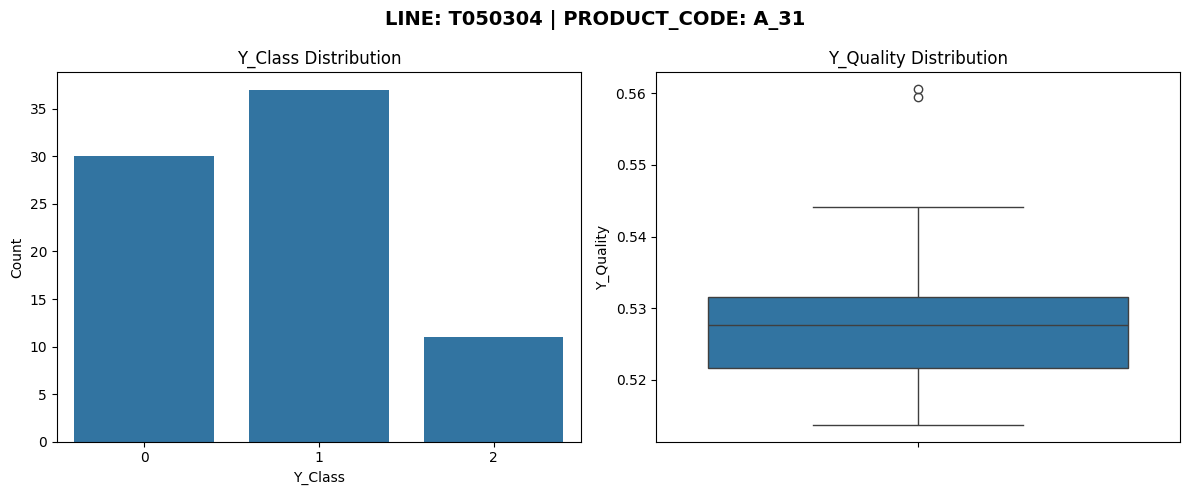

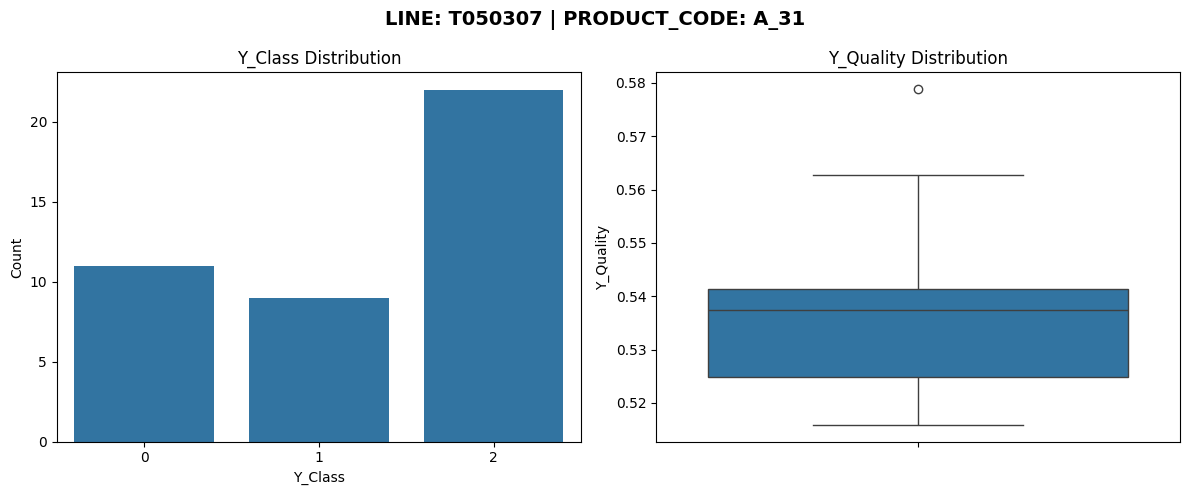

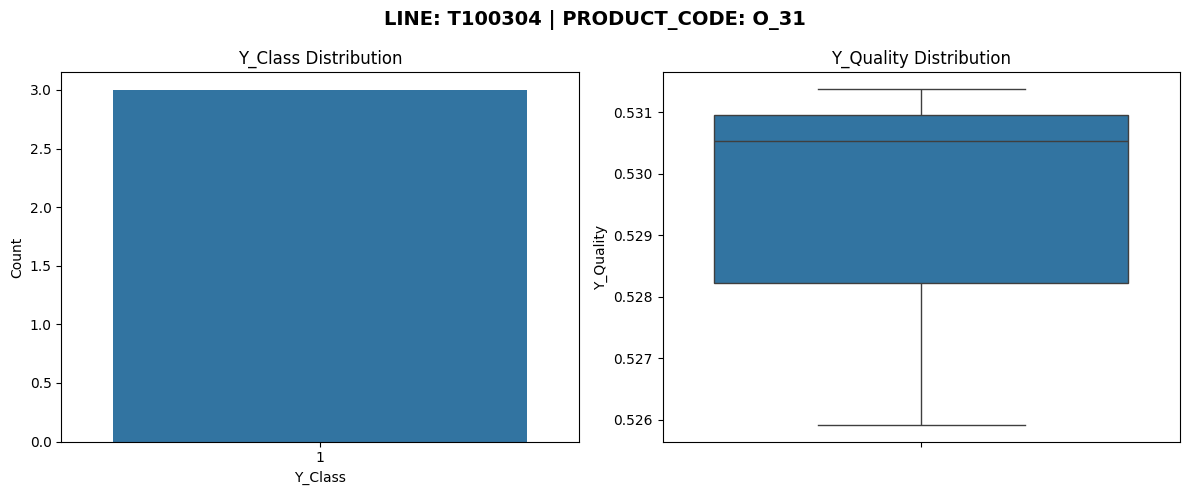

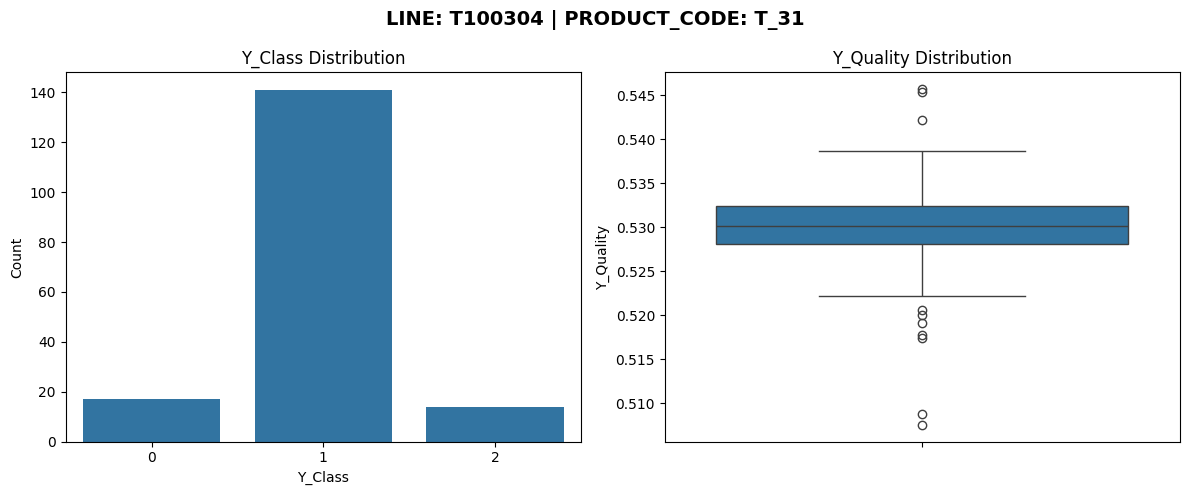

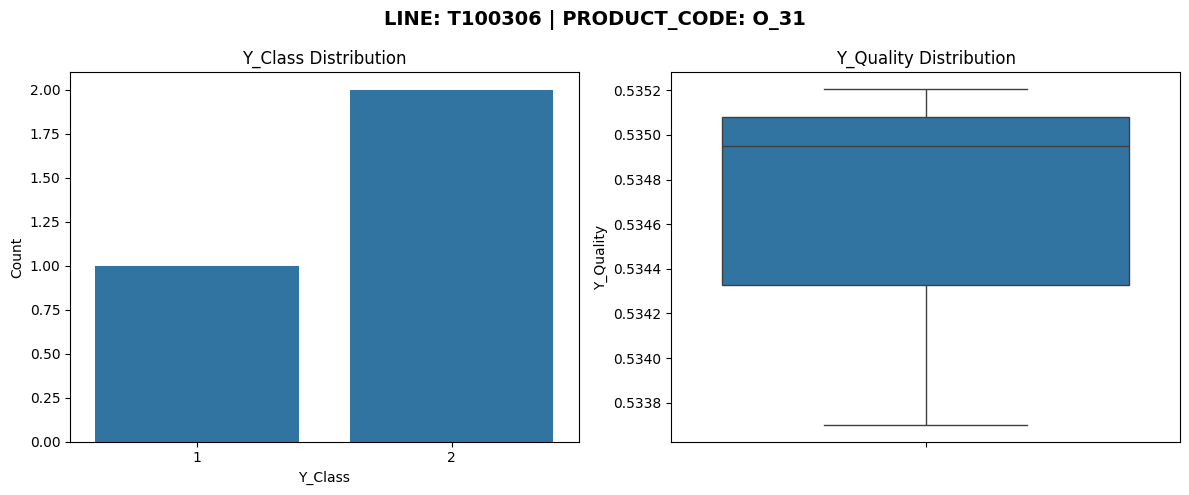

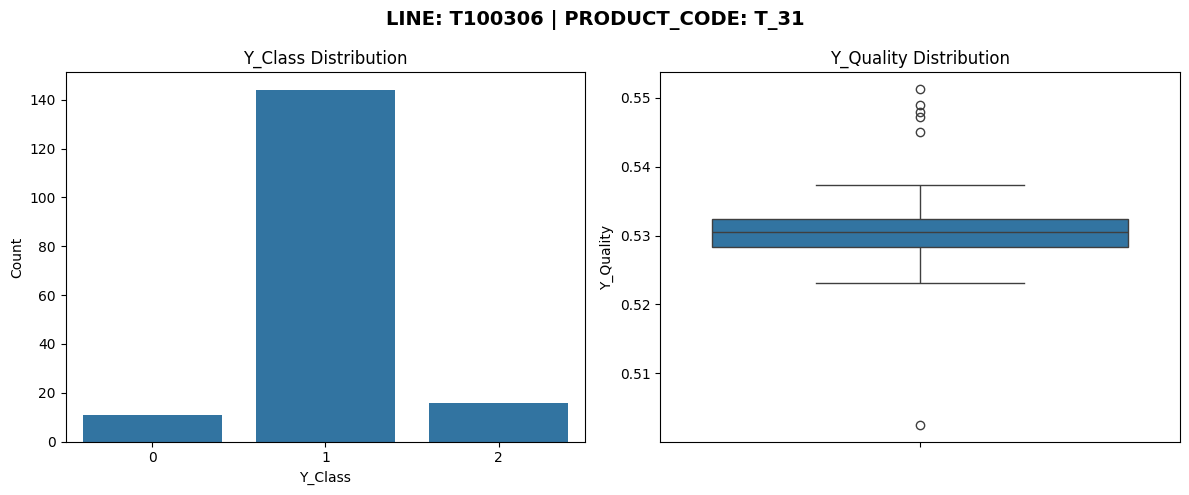

In [110]:
# 모든 (LINE, PRODUCT_CODE) 조합 확인
line_product_combinations = df.groupby(["LINE", "PRODUCT_CODE"])

# 그래프 그리기
for (line, product_code), subset in line_product_combinations:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"LINE: {line} | PRODUCT_CODE: {product_code}", fontsize=14, fontweight="bold")

    # Y_Class 분포 (막대 그래프)
    sns.countplot(data = subset, x="Y_Class", ax=axes[0])
    axes[0].set_title("Y_Class Distribution")
    axes[0].set_xlabel("Y_Class")
    axes[0].set_ylabel("Count")

    # Y_Quality 분포 (박스 플롯)
    sns.boxplot(data = subset, y="Y_Quality", ax=axes[1])
    axes[1].set_title("Y_Quality Distribution")
    axes[1].set_ylabel("Y_Quality")

    plt.tight_layout()
    plt.show()

In [112]:
from sklearn.preprocessing import LabelEncoder

# 'LINE'과 'PRODUCT_CODE_encoded'의 조합을 하나의 문자열로 결합
df['LINE_PRODUCT_COMBINATION'] = df['LINE'].astype(str) + '_' + df['PRODUCT_CODE'].astype(str)

# LabelEncoder를 사용하여 고유한 숫자 레이블 부여
label_encoder = LabelEncoder()
df['LINE_LABEL'] = label_encoder.fit_transform(df['LINE'])

# LabelEncoder를 사용하여 고유한 숫자 레이블 부여
label_encoder = LabelEncoder()
df['PRODUCT_LABEL'] = label_encoder.fit_transform(df['PRODUCT_ID'])

# LabelEncoder를 사용하여 고유한 숫자 레이블 부여
label_encoder = LabelEncoder()
df['LINE_PRODUCT_LABEL'] = label_encoder.fit_transform(df['LINE_PRODUCT_COMBINATION'])

df = df.drop(["LINE", "PRODUCT_CODE", "LINE_PRODUCT_COMBINATION", "TIMESTAMP", "PRODUCT_ID", "Time_of_Day"], axis = 1)

df.head()

,Y_Class,Y_Quality,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,...,X_2873,X_2874,X_2875,Month,Hour,Day,Minute,LINE_LABEL,PRODUCT_LABEL,LINE_PRODUCT_LABEL
0,1,0.533433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,14,2,0,2
1,2,0.541819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,22,3,1,3
2,1,0.531267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,30,2,2,2
3,2,0.537325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,39,3,3,3
4,1,0.531590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,47,2,4,2


In [113]:
# 결측 비율 계산
missing_ratio = df.isnull().mean()

# 결측 비율이 높은 순서대로 정렬
missing_ratio_sorted = missing_ratio.sort_values(ascending=False)

threshold = 0.9
high_missing_cols = missing_ratio_sorted[missing_ratio_sorted > threshold]
print(f"\n결측 비율 {threshold*100}% 이상인 컬럼 수: {len(high_missing_cols)}")
print(high_missing_cols)


결측 비율 90.0% 이상인 컬럼 수: 184
X_2644    1.000000
X_2650    1.000000
X_2664    1.000000
X_2663    1.000000
X_2662    1.000000
            ...   
X_362     0.901338
X_361     0.901338
X_360     0.901338
X_372     0.901338
X_339     0.901338
Length: 184, dtype: float64


C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\3221366281.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_data_by_group = df.groupby('LINE_LABEL').apply(lambda x: x.isnull().mean())


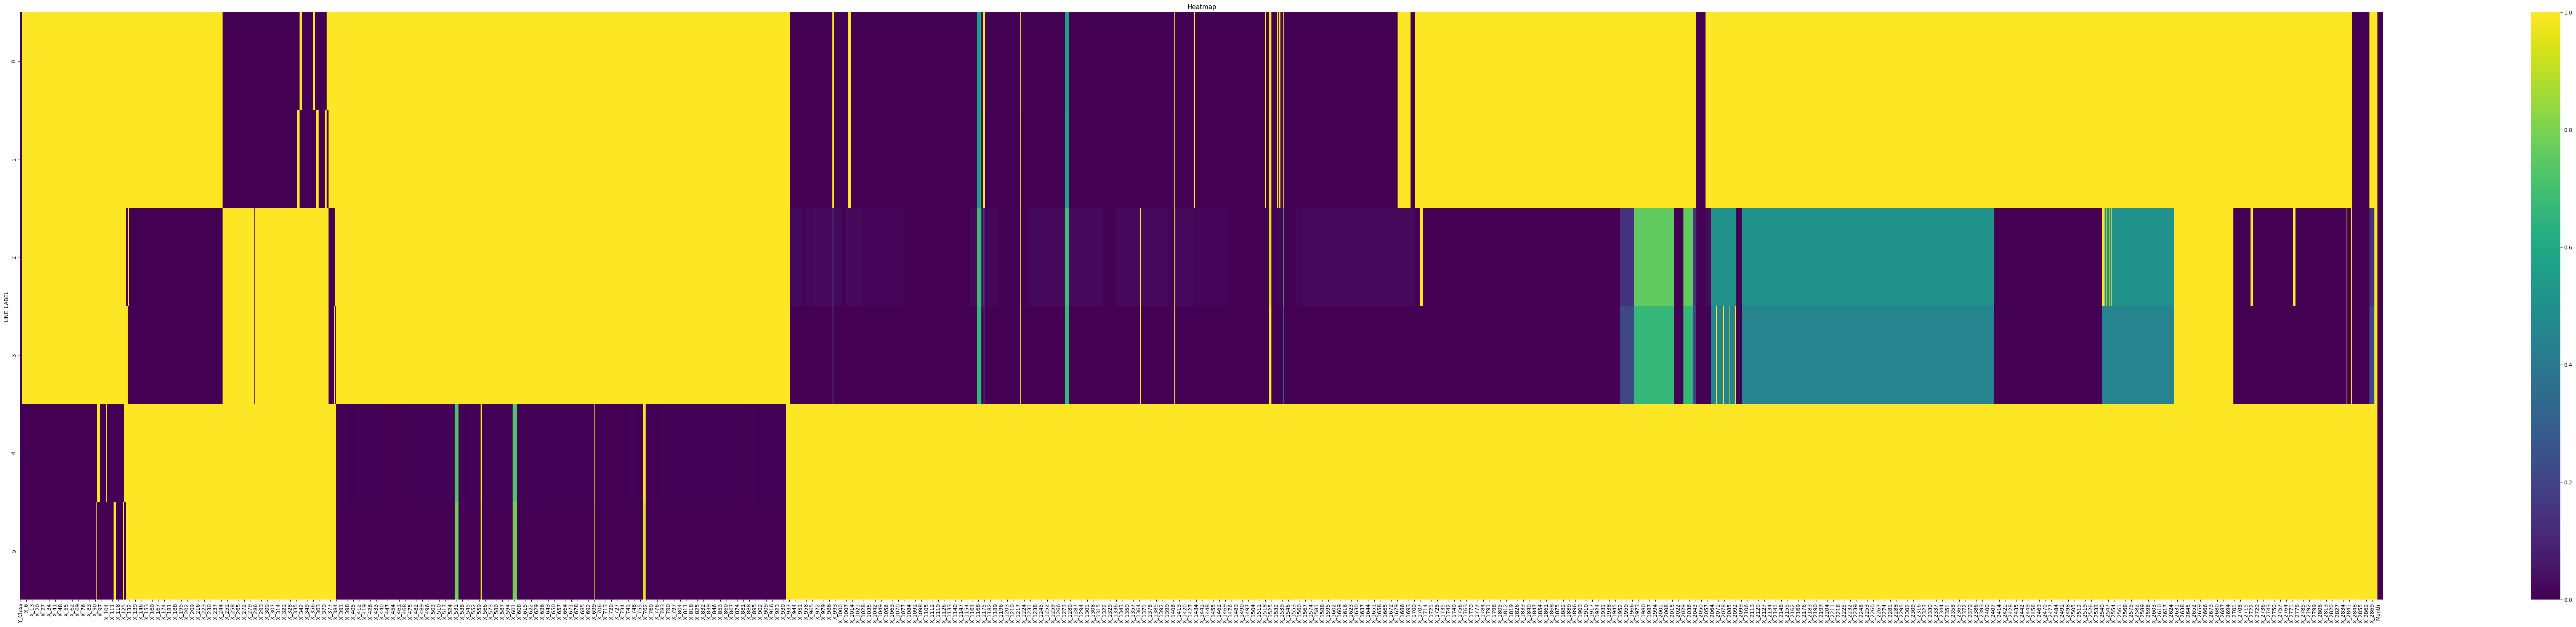

In [114]:
# LINE_PRODUCT_LABEL 단위로 그룹화하여 결측치 비율을 계산
missing_data_by_group = df.groupby('LINE_LABEL').apply(lambda x: x.isnull().mean())

# 결측치 비율이 높은 열을 보여주기 위해 결측 비율이 50% 이상인 열만 필터링
high_missing_columns = missing_data_by_group.loc[:, missing_data_by_group.max() >= 0]


# 결측치 비율이 50% 이상인 열만 필터링하여 시각화
plt.figure(figsize=(100, 20))
sns.heatmap(high_missing_columns, cmap='viridis', annot = False, cbar = True)
plt.title("Heatmap")
plt.show()

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\32334779.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_data_by_group = df.groupby('LINE_PRODUCT_LABEL').apply(lambda x: x.isnull().mean())


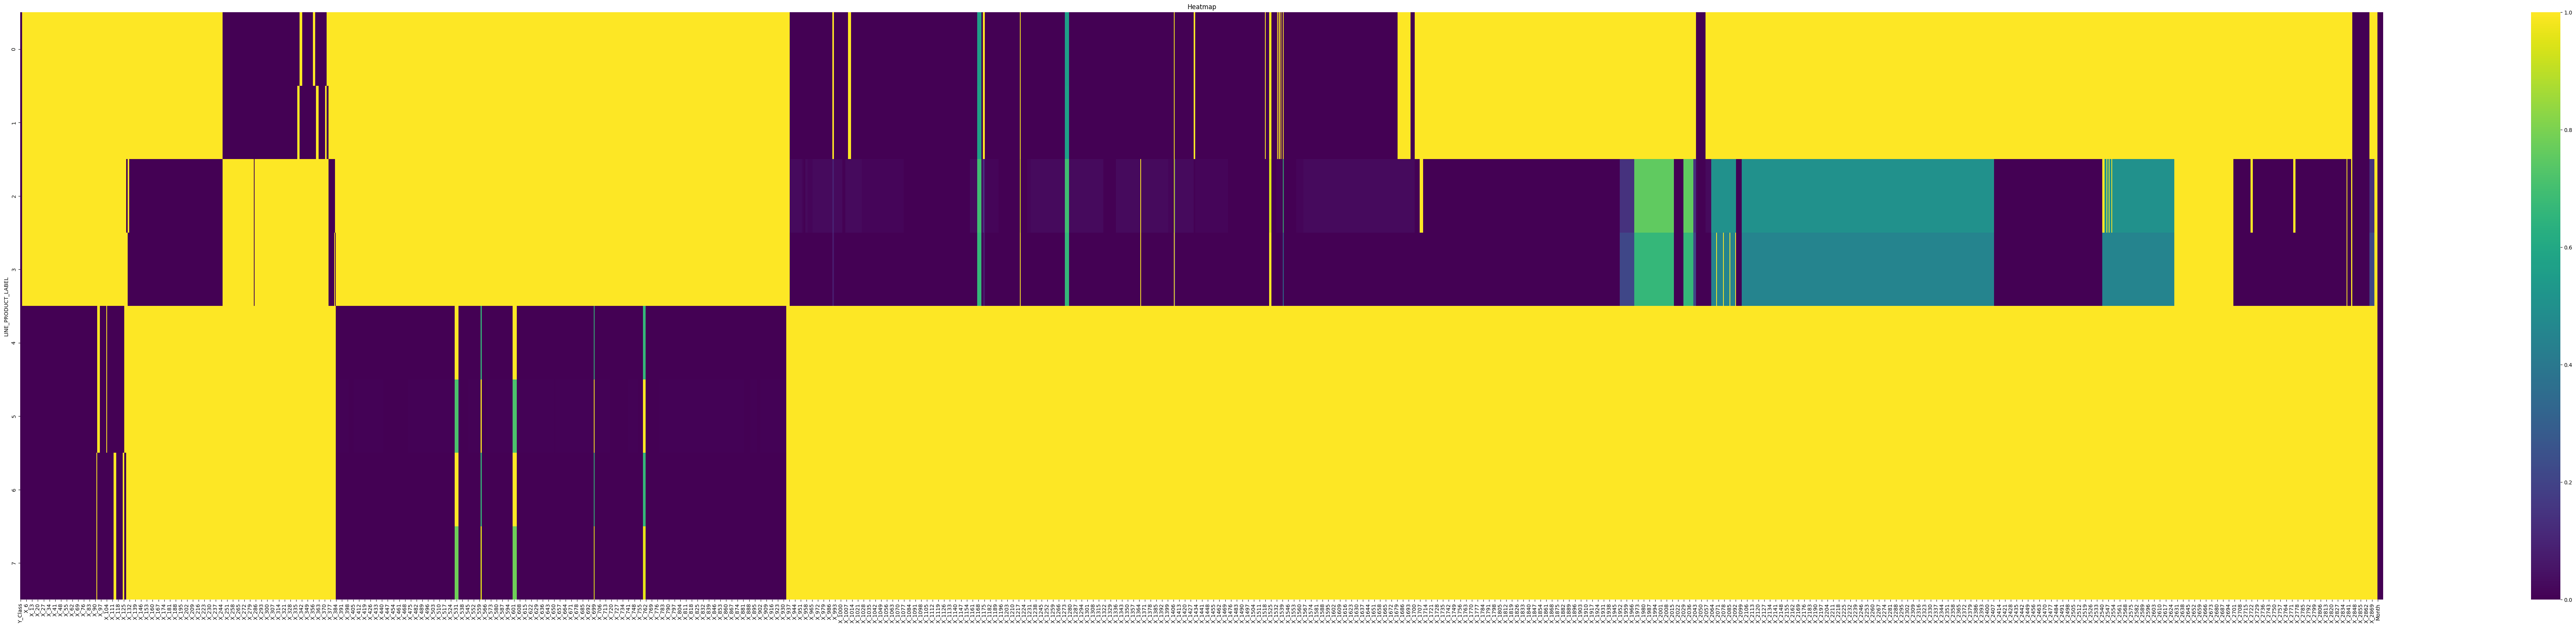

,Y_Class,Y_Quality,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,...,X_2873,X_2874,X_2875,Month,Hour,Day,Minute,LINE_LABEL,PRODUCT_LABEL,LINE_PRODUCT_LABEL
0,1,0.533433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,14,2,0,2
1,2,0.541819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,22,3,1,3
2,1,0.531267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,30,2,2,2
3,2,0.537325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,39,3,3,3
4,1,0.531590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6,5,13,47,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,1,0.526546,2.0,95.0,0.0,45.0,10.0,0.0,50.0,10.0,...,NaN,NaN,NaN,9,14,8,30,5,593,7
594,0,0.524022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,9,22,8,38,2,594,2
595,0,0.521289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,9,22,8,47,2,595,2
596,1,0.531375,40.0,94.0,0.0,45.0,11.0,0.0,45.0,10.0,...,NaN,NaN,NaN,9,14,8,38,4,596,4


In [115]:
# LINE_PRODUCT_LABEL 단위로 그룹화하여 결측치 비율을 계산
missing_data_by_group = df.groupby('LINE_PRODUCT_LABEL').apply(lambda x: x.isnull().mean())

# 결측치 비율이 높은 열을 보여주기 위해 결측 비율이 50% 이상인 열만 필터링
high_missing_columns = missing_data_by_group.loc[:, missing_data_by_group.max() >= 0]


# 결측치 비율이 50% 이상인 열만 필터링하여 시각화
plt.figure(figsize=(100, 20))
sns.heatmap(high_missing_columns, cmap='viridis', annot = False, cbar = True)
plt.title("Heatmap")
plt.show()

df

In [116]:
from sklearn.preprocessing import MinMaxScaler

# X 컬럼 추출
x_cols = df.columns[df.columns.str.startswith('X')].tolist()

# 그룹 매핑 함수
def map_line_group(label):
    if label in [0, 1]:
        return 0
    elif label in [2, 3]:
        return 1
    elif label in [4, 6]:
        return 2
    elif label in [5, 7]:
        return 3
    else:
        return -1

# 학습 데이터에 그룹 라벨 추가
df['LINE_GROUP_LABEL'] = df['LINE_PRODUCT_LABEL'].apply(map_line_group)

# 그룹별 스케일러 저장 딕셔너리
group_scalers = {}

# 그룹별 정규화 및 스케일러 저장
for group_label in df['LINE_GROUP_LABEL'].unique():
    idx = df['LINE_GROUP_LABEL'] == group_label
    scaler = MinMaxScaler()
    df.loc[idx, x_cols] = scaler.fit_transform(df.loc[idx, x_cols])
    group_scalers[group_label] = scaler  # 저장

# 보조 컬럼 제거
df.drop(columns=['LINE_GROUP_LABEL'], inplace=True)

df = df.fillna(df.mean())
df = df.dropna(axis = 1)
df

c:\Users\twoh0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\twoh0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
c:\Users\twoh0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\twoh0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
c:\Users\twoh0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\twoh0\AppDa

,Y_Class,Y_Quality,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,...,X_2869,X_2870,X_2871,Month,Hour,Day,Minute,LINE_LABEL,PRODUCT_LABEL,LINE_PRODUCT_LABEL
0,1,0.533433,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.122283,0.890487,0.0,6,5,13,14,2,0,2
1,2,0.541819,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.164742,0.601770,0.0,6,5,13,22,3,1,3
2,1,0.531267,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.205163,0.922566,0.0,6,5,13,30,2,2,2
3,2,0.537325,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.003057,0.559181,0.0,6,5,13,39,3,3,3
4,1,0.531590,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.088315,0.846239,0.0,6,5,13,47,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,1,0.526546,0.009804,0.533333,0.0,0.0,0.00000,0.0,0.294118,0.000000,...,0.719083,0.275426,0.0,9,14,8,30,5,593,7
594,0,0.524022,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.835938,0.266593,0.0,9,22,8,38,2,594,2
595,0,0.521289,0.016251,0.542605,0.0,0.0,0.39255,0.0,0.223959,0.048711,...,0.719083,0.275426,0.0,9,22,8,47,2,595,2
596,1,0.531375,1.000000,0.538462,0.0,0.0,1.00000,0.0,0.000000,0.000000,...,0.719083,0.275426,0.0,9,14,8,38,4,596,4


C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\3738597277.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = abs(corr_with_target.values), y=corr_with_target.index, palette='viridis')


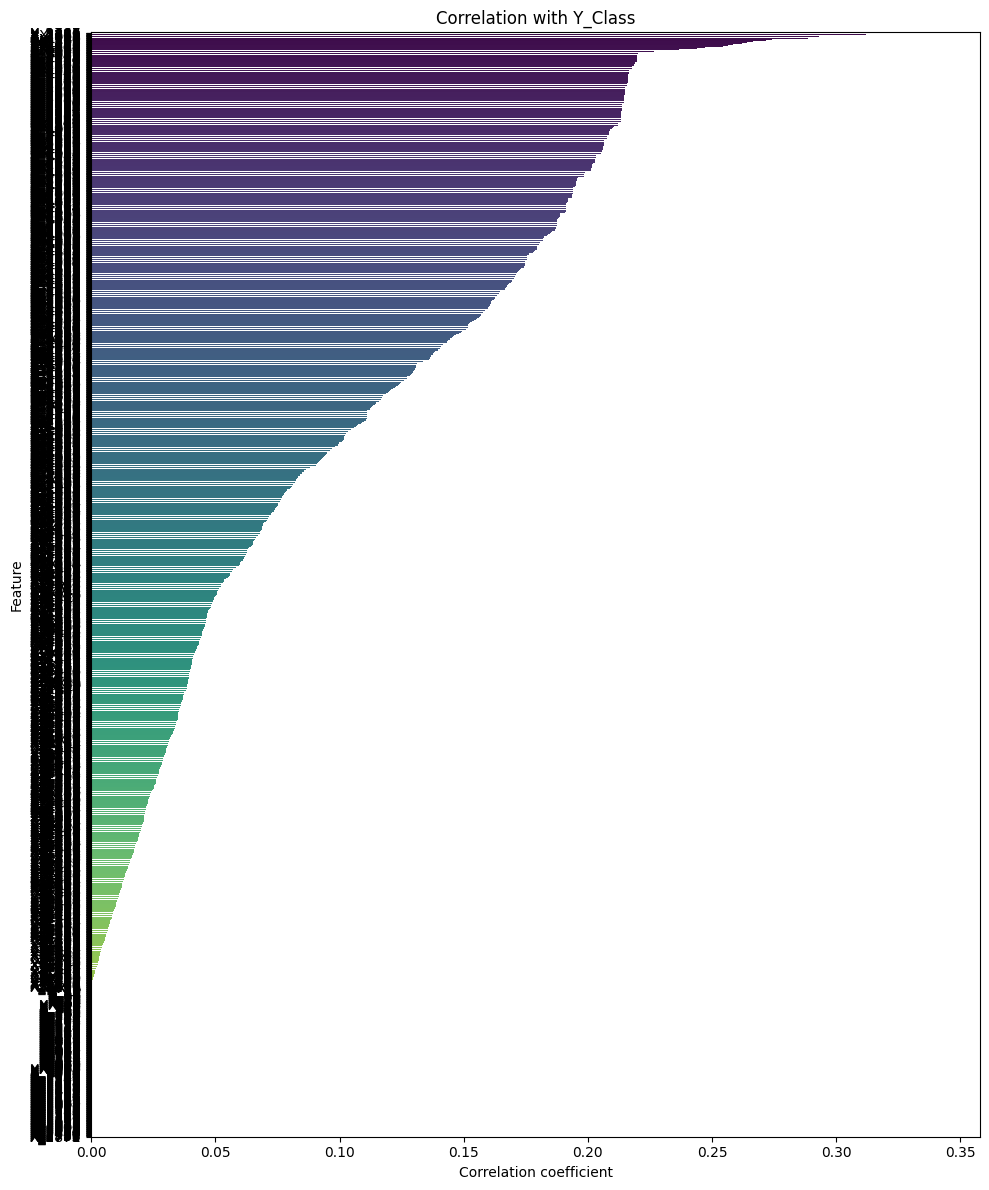

['X_2787', 'X_2466', 'X_1833', 'X_2841', 'X_2779', 'X_240', 'X_2788', 'X_2467', 'X_1849', 'X_2061', 'X_1010', 'X_1012', 'X_2791', 'X_2790', 'X_189', 'X_242', 'X_243', 'X_2780', 'X_1781', 'X_368', 'X_367', 'X_318', 'X_2789', 'X_257', 'X_1763', 'X_131', 'X_130', 'X_1720', 'X_256', 'X_2047', 'X_335', 'X_258', 'X_2046', 'X_1793', 'X_2044', 'X_1859', 'X_267', 'X_265', 'X_2731', 'X_266', 'X_248', 'X_2418', 'X_1857', 'X_2026', 'X_1751', 'X_1949', 'X_1937', 'X_2801', 'X_1818', 'X_1629', 'X_2096', 'X_1879', 'X_1873', 'X_287', 'X_2608', 'X_2389', 'X_2245', 'X_2242', 'X_2315', 'X_2243', 'X_2609', 'X_2607', 'X_2165', 'X_2314', 'X_2162', 'X_2163', 'X_2164', 'X_2316', 'X_2606', 'X_2244', 'X_2386', 'X_2387', 'X_2388', 'X_2317', 'X_1782', 'X_2187', 'X_2547', 'X_1667', 'X_1162', 'X_2533', 'X_2532', 'X_2833', 'X_221', 'X_1714', 'X_2400', 'X_2401', 'X_2620', 'X_2177', 'X_2257', 'X_2256', 'X_2621', 'X_2329', 'X_2328', 'X_2176', 'X_290', 'X_1948', 'X_2612', 'X_2320', 'X_2169', 'X_2321', 'X_2613', 'X_2249',

In [117]:
# X로 시작하는 수치형 컬럼 선택
x_cols = df.columns[df.columns.str.startswith('X')].tolist()

# 상관관계 계산
corr = df[x_cols + ['Y_Class']].corr()

# Y_Class 기준 상관계수 정렬 (상위 몇 개만 보기 원할 수도 있음)
corr_with_target = corr['Y_Class'].drop('Y_Class').sort_values(key = abs, ascending=False)

# 시각화
plt.figure(figsize=(10, 12))
sns.barplot(x = abs(corr_with_target.values), y=corr_with_target.index, palette='viridis')
plt.title('Correlation with Y_Class')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features = corr_with_target.head(400).index.tolist()
print(top_features)

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\1573274055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')


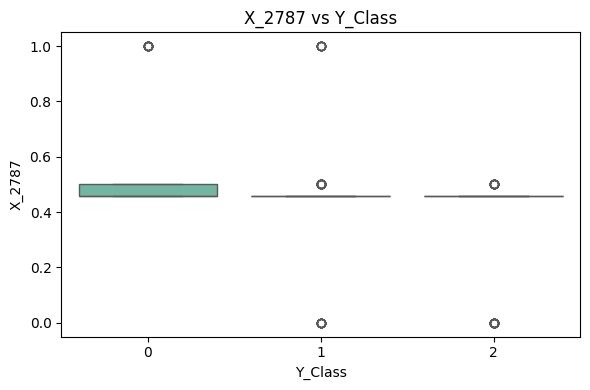

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\1573274055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')


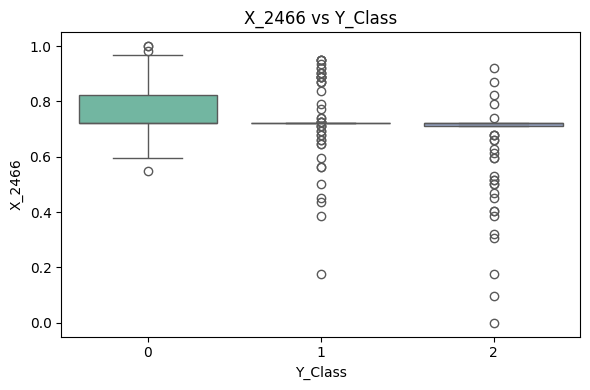

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\1573274055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')


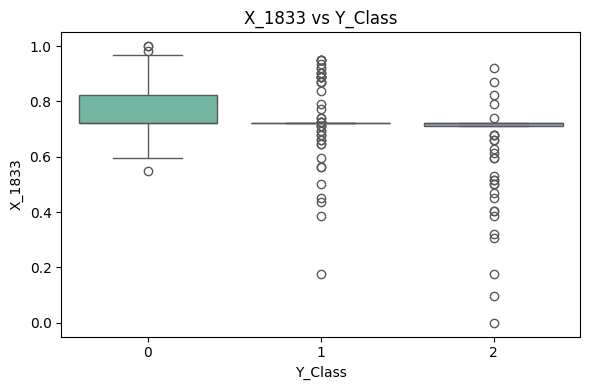

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\1573274055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')


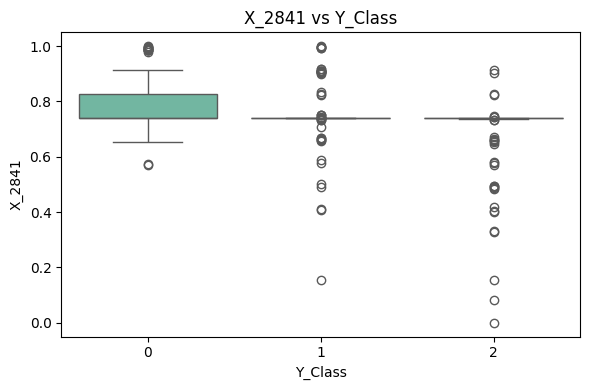

C:\Users\twoh0\AppData\Local\Temp\ipykernel_19536\1573274055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')


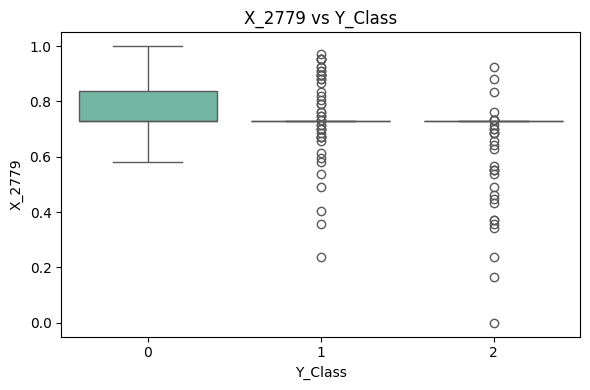

In [118]:
# 예시로 상위 상관 특성 5개만 boxplot
top_features = corr_with_target.head(5).index.tolist()

for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Y_Class', y=col, data = df, palette='Set2')
    plt.title(f'{col} vs Y_Class')
    plt.tight_layout()
    plt.show()

In [119]:
df["Y_Class"].value_counts()

Y_Class
1    407
2    103
0     88
Name: count, dtype: int64

In [120]:
test = pd.read_csv("test.csv")

from sklearn.preprocessing import LabelEncoder

def preprocessing_Line_Product(df):
    # 'LINE'과 'PRODUCT_CODE_encoded'의 조합을 하나의 문자열로 결합
    df['LINE_PRODUCT_COMBINATION'] = df['LINE'].astype(str) + '_' + df['PRODUCT_CODE'].astype(str)

    # LabelEncoder를 사용하여 고유한 숫자 레이블 부여
    label_encoder = LabelEncoder()
    df['LINE_PRODUCT_LABEL'] = label_encoder.fit_transform(df['LINE_PRODUCT_COMBINATION'])

    df = df.drop(["LINE", "PRODUCT_CODE", "LINE_PRODUCT_COMBINATION"], axis = 1)

    return df

test_ = preprocessing_Line_Product(test)

test_["LINE_PRODUCT_LABEL"].value_counts()

LINE_PRODUCT_LABEL
7    131
5    108
3     26
0     14
1     14
2     13
4      3
6      1
Name: count, dtype: int64